In [ ]:
"""
Data Production - builds geo_OiDj_merged by adding lat/lon from ZoneCodes and Ippkm,Ipps computed columns.
Geography impacts using geo located zone impact data. Following code blocks need this for plotting
how network affects impacts and how geography affects impacts.
"""

import pandas as pd

ZoneCodesFilename = r'data/DAFNI_SCQUAIR/EWS_ZoneCodes.xml'
single_links_file = r'outputs/OiDj_merged.csv'
output_file = r'outputs/geo_OiDj_merged.csv'

#load zone codes xml file into a pandas dataframe
with open(ZoneCodesFilename) as f:
    df_ZoneCodes = pd.read_xml(f)
    print(df_ZoneCodes.head(10))
    print("ZoneCodes has "+str(len(df_ZoneCodes.index))+" rows")

N = len(df_ZoneCodes.index)
df_ZoneCodes.set_index('zonei') #make sure we're adding the numpy arrays from countOneLinkScenarios in the zonei order

#now join the single links file with the zonecodes based on origin and destination zone i and j
df_single_links = pd.read_csv(single_links_file)
df = pd.merge(df_single_links,df_ZoneCodes,left_on='net_i',right_on='zonei')
df.rename(columns={
    'lat':'net_i_lat', 'lon':'net_i_lon', 'osgb36_east':'net_i_osgb36_east', 'osgb36_north':'net_i_osgb36_north',
    'area':'net_i_area', 'zonei':'net_i_zonei'
}, inplace=True)
df = pd.merge(df,df_ZoneCodes,left_on='net_j',right_on='zonei')
df.rename(columns={
    'lat':'net_j_lat', 'lon':'net_j_lon', 'osgb36_east':'net_j_osgb36_east', 'osgb36_north':'net_j_osgb36_north',
    'area':'net_j_area', 'zonei':'net_j_zonei'
}, inplace=True)
#and finally add Ippkm (persons per KM) field and Ipps
df['IppkmRoad'] = df['CkDiffRoad']/(df['scenarioLinkKMRoad']+df['scenarioLinkKMBus']+df['scenarioLinkKMRail']) #count people changing mode per KM network added
df['IppkmBus'] = df['CkDiffBus']/(df['scenarioLinkKMRoad']+df['scenarioLinkKMBus']+df['scenarioLinkKMRail'])
df['IppkmRail'] = df['CkDiffRail']/(df['scenarioLinkKMRoad']+df['scenarioLinkKMBus']+df['scenarioLinkKMRail'])
df['IppsRoad'] = df['CkDiffRoad']/(df['scenarioLinkSavedSecsRoad']+df['scenarioLinkSavedSecsBus']+df['scenarioLinkSavedSecsRail']) #count people changing mode per second of network improved
df['IppsBus'] = df['CkDiffBus']/(df['scenarioLinkSavedSecsRoad']+df['scenarioLinkSavedSecsBus']+df['scenarioLinkSavedSecsRail'])
df['IppsRail'] = df['CkDiffRail']/(df['scenarioLinkSavedSecsRoad']+df['scenarioLinkSavedSecsBus']+df['scenarioLinkSavedSecsRail'])

df.to_csv(output_file,index=False)


     areakey  zonei        lat       lon  osgb36_east  osgb36_north       area
0  E02000001      0  51.515000 -0.090516    532482.75     181269.56  2897837.5
1  E02000002      1  51.588420  0.141110    548312.70     189878.02  2161565.0
2  E02000003      2  51.575100  0.142558    548456.44     188399.88  2141516.0
3  E02000004      3  51.555622  0.178484    551010.00     186307.53  2492948.0
4  E02000005      4  51.561592  0.144949    548666.10     186902.60  1187953.0
5  E02000007      5  51.558270  0.159004    549651.06     186562.12  1735997.9
6  E02000008      6  51.552820  0.136958    548140.90     185910.88  1419999.0
7  E02000009      7  51.551743  0.119994    546968.44     185757.10   960733.6
8  E02000010      8  51.547050  0.150028    549065.60     185296.10  1121450.5
9  E02000011      9  51.545460  0.170756    550507.80     185161.84  1594084.6
ZoneCodes has 8436 rows


In [4]:
"""
Data Production - builds geo_twolinks.csv from twolinks.csv by adding lat/lon from EWS zonecodes
Output: outputs\geo_twolinks.csv which is twolinks with lat/lon and OSGB N/E added for i0,j0 and i1,j1

"""
import pandas as pd

ZoneCodesFilename = r'data/DAFNI_SCQUAIR/EWS_ZoneCodes.xml'
two_links_file = r'outputs/twolinks.csv'
output_file = r'outputs/geo_twolinks.csv'

#load zone codes xml file into a pandas dataframe
with open(ZoneCodesFilename) as f:
    df_ZoneCodes = pd.read_xml(f)
    print(df_ZoneCodes.head(10))
    print("ZoneCodes has "+str(len(df_ZoneCodes.index))+" rows")

N = len(df_ZoneCodes.index)
df_ZoneCodes.set_index('zonei') # ??? make sure we're adding the numpy arrays from countOneLinkScenarios in the zonei order

#now join the two links file with the zonecodes based on origin and destination zone i and j
df_two_links = pd.read_csv(two_links_file)
df = pd.merge(df_two_links,df_ZoneCodes,left_on='net_i_0',right_on='zonei')
df.rename(columns={
    'lat':'net_i_0_lat', 'lon':'net_i_0_lon', 'osgb36_east':'net_i_0_osgb36_east', 'osgb36_north':'net_i_0_osgb36_north',
    'area':'net_i_0_area', 'zonei':'net_i_0_zonei', 'areakey':'net_i_0_areakey'
}, inplace=True)
df = pd.merge(df,df_ZoneCodes,left_on='net_j_0',right_on='zonei')
df.rename(columns={
    'lat':'net_j_0_lat', 'lon':'net_j_0_lon', 'osgb36_east':'net_j_0_osgb36_east', 'osgb36_north':'net_j_0_osgb36_north',
    'area':'net_j_0_area', 'zonei':'net_j_0_zonei', 'areakey':'net_j_0_areakey'
}, inplace=True)
#now the second link net_i_1 and net_j_1
df = pd.merge(df,df_ZoneCodes,left_on='net_i_1',right_on='zonei')
df.rename(columns={
    'lat':'net_i_1_lat', 'lon':'net_i_1_lon', 'osgb36_east':'net_i_1_osgb36_east', 'osgb36_north':'net_i_1_osgb36_north',
    'area':'net_i_1_area', 'zonei':'net_i_1_zonei', 'areakey':'net_i_1_areakey'
}, inplace=True)
df = pd.merge(df,df_ZoneCodes,left_on='net_j_1',right_on='zonei')
df.rename(columns={
    'lat':'net_j_1_lat', 'lon':'net_j_1_lon', 'osgb36_east':'net_j_1_osgb36_east', 'osgb36_north':'net_j_1_osgb36_north',
    'area':'net_j_1_area', 'zonei':'net_j_1_zonei', 'areakey':'net_j_1_areakey'
}, inplace=True)
#NOTE: remember that there are two links: net_i_0 -> net_j_0 and net_i_1 -> net_j_1
#and they're connected, so net_j_0==net_i_1
df.to_csv(output_file,index=False)



     areakey  zonei        lat       lon  osgb36_east  osgb36_north       area
0  E02000001      0  51.515000 -0.090516    532482.75     181269.56  2897837.5
1  E02000002      1  51.588420  0.141110    548312.70     189878.02  2161565.0
2  E02000003      2  51.575100  0.142558    548456.44     188399.88  2141516.0
3  E02000004      3  51.555622  0.178484    551010.00     186307.53  2492948.0
4  E02000005      4  51.561592  0.144949    548666.10     186902.60  1187953.0
5  E02000007      5  51.558270  0.159004    549651.06     186562.12  1735997.9
6  E02000008      6  51.552820  0.136958    548140.90     185910.88  1419999.0
7  E02000009      7  51.551743  0.119994    546968.44     185757.10   960733.6
8  E02000010      8  51.547050  0.150028    549065.60     185296.10  1121450.5
9  E02000011      9  51.545460  0.170756    550507.80     185161.84  1594084.6
ZoneCodes has 8436 rows


unfiltered bus data contains  156703 values
filtered bus data contains  156616 values
total count of rows:  456361
Correlation savedSecs Road r= 0.4723671088702841 rho= 0.904250112981085 tau= 0.7238239903840584
Correlation savedSecs Bus r= 0.6042898396599798 rho= 0.8665351244237298 tau= 0.6842800036978826
Correlation savedSecs Rail r= 0.888474850201598 rho= 0.8859877187510011 tau= 0.7176159272170639
Correlation nMinus Road r= 0.4715639669302004 rho= 0.8644574923793031 tau= 0.6718611474938838
Correlation nMinus Bus r= 0.4997322712627803 rho= 0.8108394090053499 tau= 0.6239047590638782
Correlation nMinus Rail r= 0.8242744290941544 rho= 0.8423517872577594 tau= 0.6606367381868217


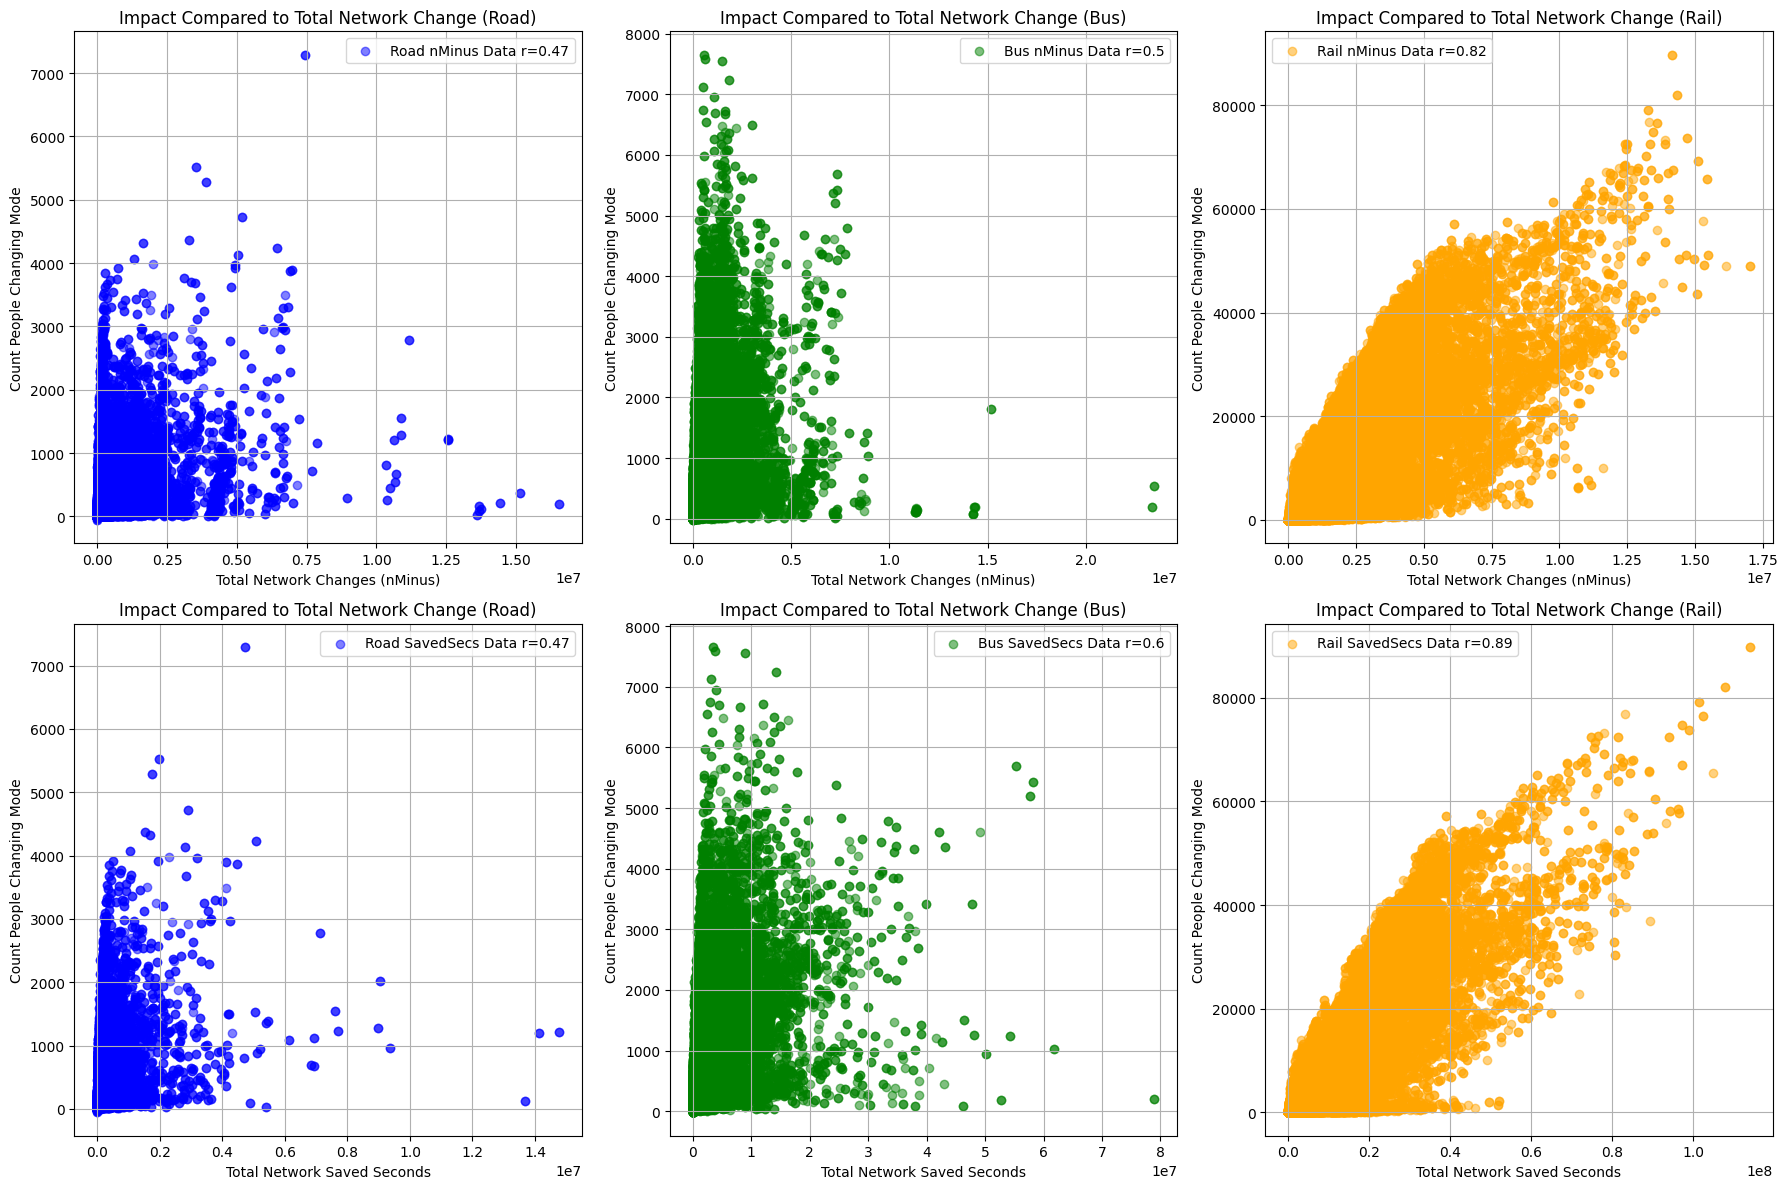

In [3]:
"""
Now do something with the data!!!
"""
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt

geo_input_file =r'outputs/geo_OiDj_merged.csv'

df = pd.read_csv(geo_input_file)
#for Bus, drop CkDiff>8000 No! savesSecsBus>2e9
#df.drop(df[(df['CkDiffBus'] > 8000) & (df['net_mode']==1)].index, inplace=True)
dfBusExtremes = df[(df['savedSecsBus'] > 2e9) & (df['net_mode']==1)]
dfBusExtremes.to_csv(r'outputs/busextremevalues.csv')
#TODO: now we know all the bus extreme values are around Glasgow, we need a map - AND A REASON!!!
print("unfiltered bus data contains ",len(df[(df['net_mode']==1)].index),"values")
df.drop(df[(df['savedSecsBus'] > 2e9) & (df['net_mode']==1)].index, inplace=True)
print("filtered bus data contains ",len(df[(df['net_mode']==1)].index),"values")
print("total count of rows: ",len(df))


fig, axes = plt.subplots(2, 3, figsize=(18, 12))

modes = {0: 'Road', 1: 'Bus', 2: 'Rail'}
colors = {0: 'blue', 1: 'green', 2: 'orange'}

# Function to filter out extreme values - RWM - I don't think this works - better just to remove extreme bus values (savesSecsBus>2e9)
def filter_extreme_values(df, column, factor=10):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

for mode, label in modes.items():
    #ax = axes[2, mode]
    ax = axes[1,mode]
    mode_df = df[df['net_mode'] == mode]
    filtered_df = mode_df #filter_extreme_values(mode_df, 'savedSecs'+label, 10.0)
    #r = np.corrcoef(filtered_df['savedSecs'+label], filtered_df['CkDiff'+label]) #Pearson r corr coeff
    r = scipy.stats.pearsonr(filtered_df['savedSecs'+label], filtered_df['CkDiff'+label]).correlation #Pearson r
    rho = scipy.stats.spearmanr(filtered_df['savedSecs'+label], filtered_df['CkDiff'+label]).correlation #Spearman's rho
    tau = scipy.stats.kendalltau(filtered_df['savedSecs'+label], filtered_df['CkDiff'+label]).correlation #Kendall's tau
    print('Correlation savedSecs',label,'r=',r,'rho=',rho,'tau=',tau)
    ax.scatter(filtered_df['savedSecs'+label], filtered_df['CkDiff'+label], alpha=0.5, color=colors[mode], label=f'{label} SavedSecs Data r='+str(round(r,2)))
    ax.set_xlabel('Total Network Saved Seconds')
    ax.set_ylabel('Count People Changing Mode')
    ax.set_title(f'Impact Compared to Total Network Change ({label})')
    ax.legend()
    ax.grid(True)

for mode, label in modes.items():
    #ax = axes[2, mode]
    ax = axes[0,mode]
    mode_df = df[df['net_mode'] == mode]
    filtered_df = mode_df #filter_extreme_values(mode_df, 'nMinus'+label, 10.0)
    #r = np.corrcoef(filtered_df['nMinus'+label], filtered_df['CkDiff'+label]) #Pearson r corr coeff
    r = scipy.stats.pearsonr(filtered_df['nMinus'+label], filtered_df['CkDiff'+label]).correlation #Pearson r
    rho = scipy.stats.spearmanr(filtered_df['nMinus'+label], filtered_df['CkDiff'+label]).correlation #Spearman's rho
    tau = scipy.stats.kendalltau(filtered_df['nMinus'+label], filtered_df['CkDiff'+label]).correlation #Kendall's tau
    print('Correlation nMinus',label,'r=',r,'rho=',rho,'tau=',tau)
    ax.scatter(filtered_df['nMinus'+label], filtered_df['CkDiff'+label], alpha=0.5, color=colors[mode], label=f'{label} nMinus Data r='+str(round(r,2)))
    ax.set_xlabel('Total Network Changes (nMinus)')
    ax.set_ylabel('Count People Changing Mode')
    ax.set_title(f'Impact Compared to Total Network Change ({label})')
    ax.legend()
    ax.grid(True)

#removed Ippsecs graph as it doesn't show anything useful for this data
# for mode, label in modes.items():
#     #ax = axes[2, mode]
#     ax = axes[2,mode]
#     mode_df = df[df['net_mode'] == mode]
#     filtered_df = mode_df #filter_extreme_values(mode_df, 'Ipps'+label)
#     r = scipy.stats.pearsonr(filtered_df['savedSecs'+label], filtered_df['Ipps'+label]).correlation #Pearson r
#     rho = scipy.stats.spearmanr(filtered_df['savedSecs'+label], filtered_df['Ipps'+label]).correlation #Spearman's rho
#     tau = scipy.stats.kendalltau(filtered_df['savedSecs'+label], filtered_df['Ipps'+label]).correlation #Kendall's tau
#     print('Correlation savedSecs Ipps',label,'r=',r,'rho=',rho,'tau=',tau)
#     ax.scatter(filtered_df['savedSecs'+label], filtered_df['Ipps'+label], alpha=0.5, color=colors[mode], label=f'{label} ppSecs Data')
#     ax.set_xlabel('Total Network Saved Seconds')
#     ax.set_ylabel('Person per Network Seconds')
#     ax.set_title(f'Impact Compared to Total Network Change ({label})')
#     ax.legend()
#     ax.grid(True)


plt.tight_layout()
plt.savefig('outputs/nMinus_savedSecs_CkDiff_filtered.jpg')
plt.show()